# Assignment 8
**Author:** Lan Stare
**Date:** 14. 11. 2025

### (a)

In [47]:
import matplotlib.pyplot as plt
import numpy as np

f1 = lambda x: np.sin(2 * np.pi * x)    #examples
m1 = 20
x_pts = np.linspace(-1, 1, m1 + 1)
f_values = f1(x_pts)

def plotspline(f,x):
    m = len(x) - 1      #because number of intervals
    xs_plot = []    #for plotting the full interpolant
    s_plot = []
    max_error = 0.0     #for error computation

    #loop over every interval [x[i], x[i+1]]
    for i in range(m):
        xL, xR = x[i], x[i+1]
        fL, fR = f(x)[i], f(x)[i+1]

        xx = np.linspace(xL, xR, 20)    #for error computation

        #linear interpolant on this interval:
        S1 = fL + (fR - fL) * (xx - xL) / (xR - xL)

        #update global max error
        interval_error = np.max(np.abs(f(xx) - S1))
        max_error = max(max_error, interval_error)

        #store values for plotting
        xs_plot.append(xx)
        s_plot.append(S1)

    #plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x, f(x), "o", label="Data points", markersize=6)

    #function plot
    xfine = np.linspace(x[0], x[-1], 1000)
    plt.plot(xfine, f(xfine), label="f(x)")

    #linear spline plot
    for xx, yy in zip(xs_plot, s_plot):
        plt.plot(xx, yy, "r--")

    plt.title("Piecewise Linear Interpolant (S₁)")
    plt.legend()
    plt.grid(True)
    #plt.show()
    plt.close()

    return max_error

plotspline(f1, x_pts)
        
        

0.04880678869731547

### (b)

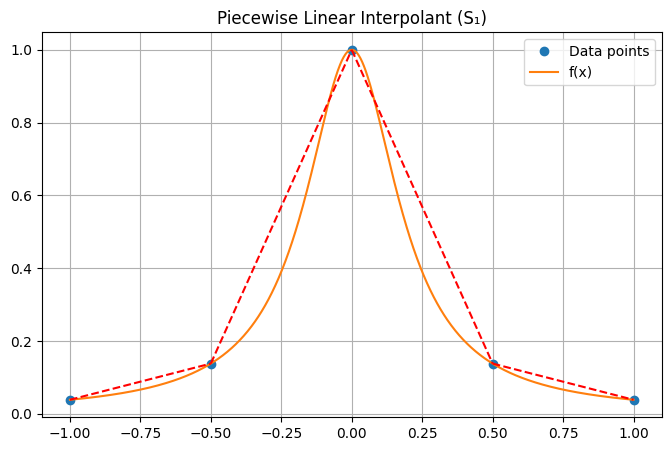

0.18015373118394368

In [28]:
f_ex = lambda x: 1/(1 + 25 * np.array(x)**2)
x_pts_ex = [-1 + 1/2 * i for i in range(5)]
plotspline(f_ex, x_pts_ex)

### (c)

[(2, 0.4181323422048185), (4, 0.18015373118394368), (8, 0.06360286537144066), (16, 0.0535063717394435), (32, 0.020700764885007272), (64, 0.0058408437482229125), (128, 0.0015059859622513772), (256, 0.000379429000300191), (512, 9.504167761242854e-05), (1024, 2.377196413483329e-05)]


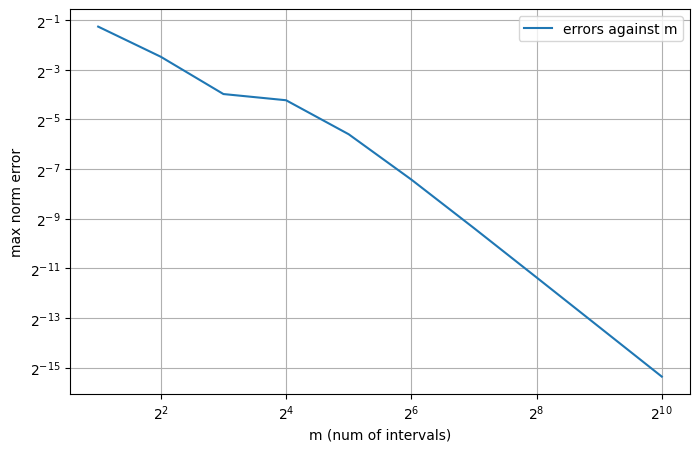

In [79]:
#given parameters
ms = [2**k for k in range(1, 11)]
errors = []

for m in ms:
    pts = [-1 + 2/m * i for i in range(m + 1)]
    errors.append(plotspline(f_ex, pts))
    
print(list(zip(ms, errors)))

plt.figure(figsize=(8, 5))
plt.loglog(ms, errors, base=2, label="errors against m")  #using base 2 because we can easier visualize m
#plt.plot(ms, errors, label="errors against m")
plt.xlabel("m (num of intervals)")
plt.ylabel("max norm error")
plt.legend()
plt.grid()
plt.show()


We have equispaced points $x_i$ and for every m and i: $h = h_i = 2/m$. Our error is bounded by: $C * h^2 * ||f^{2}||_{\infty}$ where $C \in \mathbb{R}$. If we take into account our $h$, we get: $C * (4/m^{2}) * ||f^{2}||_{\infty}$. This means that our error should decrease quadratically with m. If we take loglog plot, we transform $(2^{2}/m^{2})$ into $2* \log(2/m) = (-2) * \log(m/2)$. This means that we should expect our function to decrease linearly with a slope of (-2).

In [78]:
#verifying our fit:
ms = np.array(ms)
errors = np.array(errors)

#take logs
log_m = np.log(ms)
log_e = np.log(errors)

#linear fit: log(E) = a + b * log(m)
b, a = np.polyfit(log_m, log_e, 1)

print("Expected slope: -2, fitted slope:", b)

Expected slope: -2, fitted slope: -1.5597829046264413
